<a href="https://colab.research.google.com/github/YagoIbarrola/EML_Carrillo_Ibarrola_Palomar/blob/main/k_brazos/src/comparation_experiment.ipynb" target="_parent">
<img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# Estudio comparativo de algoritmos en un problema de k-armed bandit

*Description:* El experimento compara el rendimiento de los algoritmos epsilon-greedy, epsilon-decaimiento, UCB1, UCB2 y softmax estudiados en sus respectivos nootbooks.
Se generan gráficas de recompensas promedio para cada algoritmo.

    Authors: Ginés Carrillo Ibáñez, Yago Ibarrola Lapeña, Aarón Palomar Peña
    Emails: gines.carrilloi@um.es, yago.ibarrolal@um.es, aaron.p.p@um.es
    Date: 2026/02/06


## Preparación del entorno


In [ ]:
import sys
if 'google.colab' in sys.modules:
    # Definimos que el entorno es Colab
    en_colab = True
    print("Ejecutando en Google Colab")
else:
    # Definimos que el entorno es local
    en_colab = False
    print("Ejecutando en entorno local")

if en_colab:
    #@title Copiar el repositorio.
    print("Clonando el repositorio, tiempo estimado: 1-2 minutos...")
    !git clone https://github.com/YagoIbarrola/EML_Carrillo_Ibarrola_Palomar.git
    !cd EML_Carrillo_Ibarrola_Palomar/

    #@title Importamos todas las clases y funciones
    # Añadir los directorio fuentes al path de Python
    sys.path.append('/content/EML_Carrillo_Ibarrola_Palomar')
    # Verificar que se han añadido correctamente
    print(sys.path)

In [ ]:
import numpy as np
from typing import List

from algorithms import Algorithm, EpsilonGreedy, EpsilonDecaimiento, UCB1, UCB2, Softmax

from arms import ArmNormal, ArmBernoulli, ArmBinomial, Bandit
from plotting import plot_average_rewards, plot_optimal_selections, plot_arm_statistics, plot_regret


## Experimento

Cada algoritmo se ejecuta en un problema de k-armed bandit durante un número de pasos de tiempo y ejecuciones determinado.
Se comparan los resultados de los algoritmos en términos de recompensa promedio.

In [4]:
from utils import run_experiment

## Ejecución del experimento

Se realiza un experimento, utilizando una distribución de probabilidad normal con media $\mu\in[1,10]$ y desviación típica $\sigma=1$ de las recompensas asociadas a cada brazo. 

Se utiliza un bandido de 10 brazos. Se realizan 500 ejecuciones, cada una de 1000 pasos de tiempo. Se comparan los cinco algoritmos estudiados: $\epsilon$-greedy con $\epsilon$ = 0.01; $\epsilon$-decaimiento con epsilon inicial $\epsilon_0=1.0$, tasa de decaimiento $\lambda_{decay}=0.01$, y epsilon mínimo $\epsilon_{min}=0.01$; UCB1 con $c$=1; UCB2 con $\alpha$=0.1; softmax con temperatura $\tau=0.1$ y haciendo pasada inicial.

In [5]:
import json

# Parámetros del experimento
seed = 42
np.random.seed(seed)  # Fijar la semilla para reproducibilidad

k = 10  # Número de brazos
steps = 1000  # Número de pasos que se ejecutarán cada algoritmo
runs = 500  # Número de ejecuciones

# Para trabajar en todos los experimentos con las mismas recompensas de cada brazo, generamos los valores de mu para cada brazo una sola vez y los reutilizamos en todos los experimentos.
mu_values = set()
while len(mu_values) < k:
    mu = np.random.uniform(1.0, 10.0) # Generar un valor de mu aleatorio entre 1.0 y 10.0
    mu = round(mu, 2)
    mu_values.add(mu)

mu_values = list(mu_values)

In [6]:
# Creación del bandit

bandit = Bandit(arms=ArmNormal.generate_arms_with_fixed_means(mu_values)) # Generar un bandido con k brazos de distribución normal
print(bandit)  # Imprimir la configuración del bandido

optimal_arm = bandit.optimal_arm
print(f"Optimal arm: {optimal_arm + 1} with expected reward={bandit.get_expected_value(optimal_arm)}")

# Definir los algoritmos a comparar. En este caso son 3 algoritmos epsilon-greedy con diferentes valores de epsilon y un algoritmo epsilon-decaimiento.
algorithms = [EpsilonGreedy(k=k, epsilon=0.01), EpsilonDecaimiento(k=k, epsilon_0=1.0, lambda_decay=0.01, epsilon_min=0.01), UCB1(k=k, c=1), UCB2(k=k, alpha=0.1), Softmax(k=k, temperature=0.1, exploring=True)]

# Ejecutar el experimento y obtener las recompensas promedio y promedio de las selecciones óptimas
rewards, optimal_selections, arms_stats, regret_accumulated = run_experiment(bandit, algorithms, steps, runs)


Bandit with 10 arms: ArmNormal(mu=1.52, sigma=1.0), ArmNormal(mu=2.4, sigma=1.0), ArmNormal(mu=1.19, sigma=1.0), ArmNormal(mu=4.37, sigma=1.0), ArmNormal(mu=6.39, sigma=1.0), ArmNormal(mu=7.59, sigma=1.0), ArmNormal(mu=8.8, sigma=1.0), ArmNormal(mu=9.56, sigma=1.0), ArmNormal(mu=6.41, sigma=1.0), ArmNormal(mu=7.37, sigma=1.0)
Optimal arm: 8 with expected reward=9.56


En este experimento se genera un bandido de 10 brazos, cada uno con una distribución normal de media entre 1 y 10 y desviación típica 1. En esta instancia concreta, el brazo 8 resulta ser el óptimo, con una recompensa esperada de 9.56.

#### Visualización de los resultados

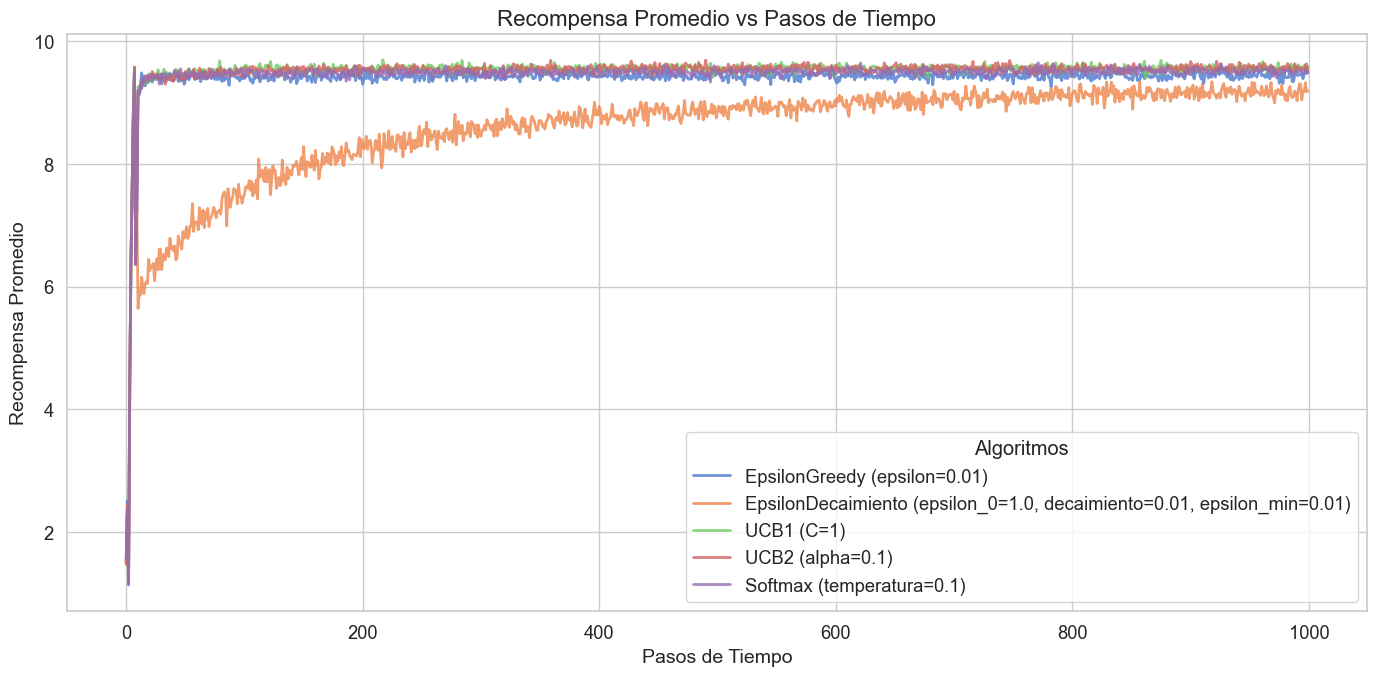

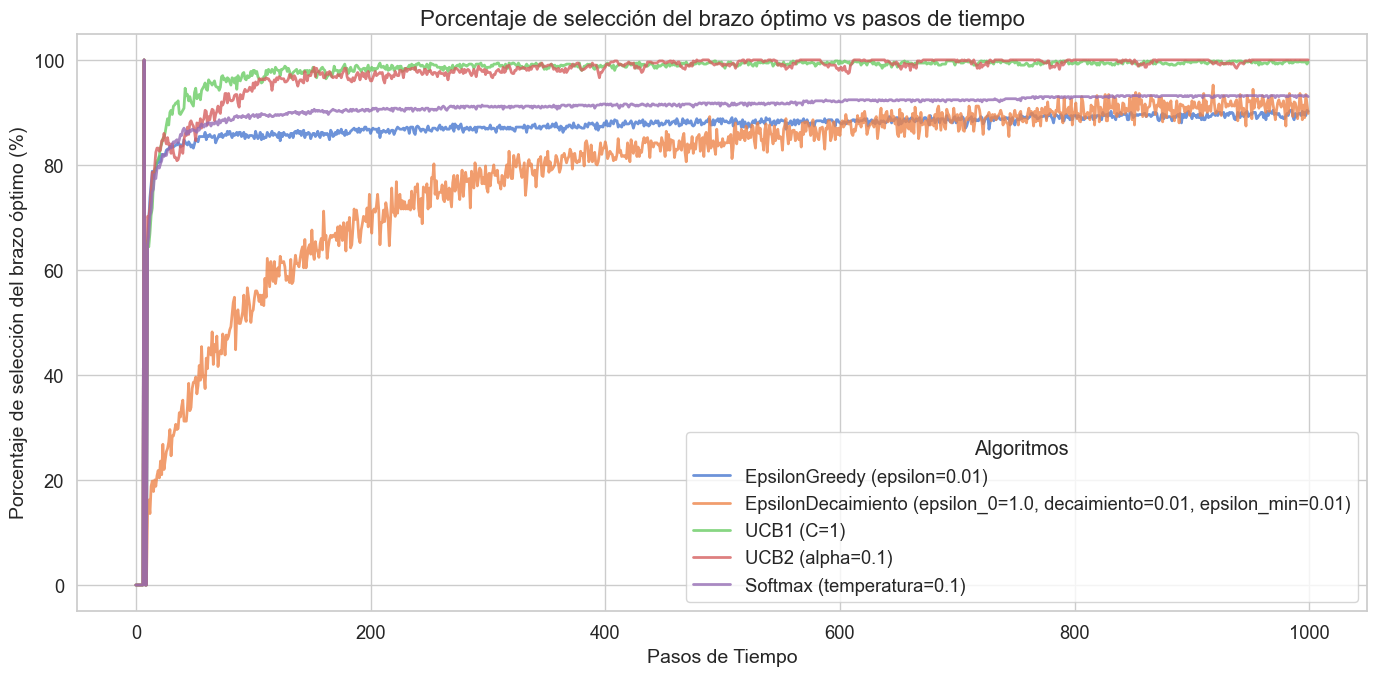

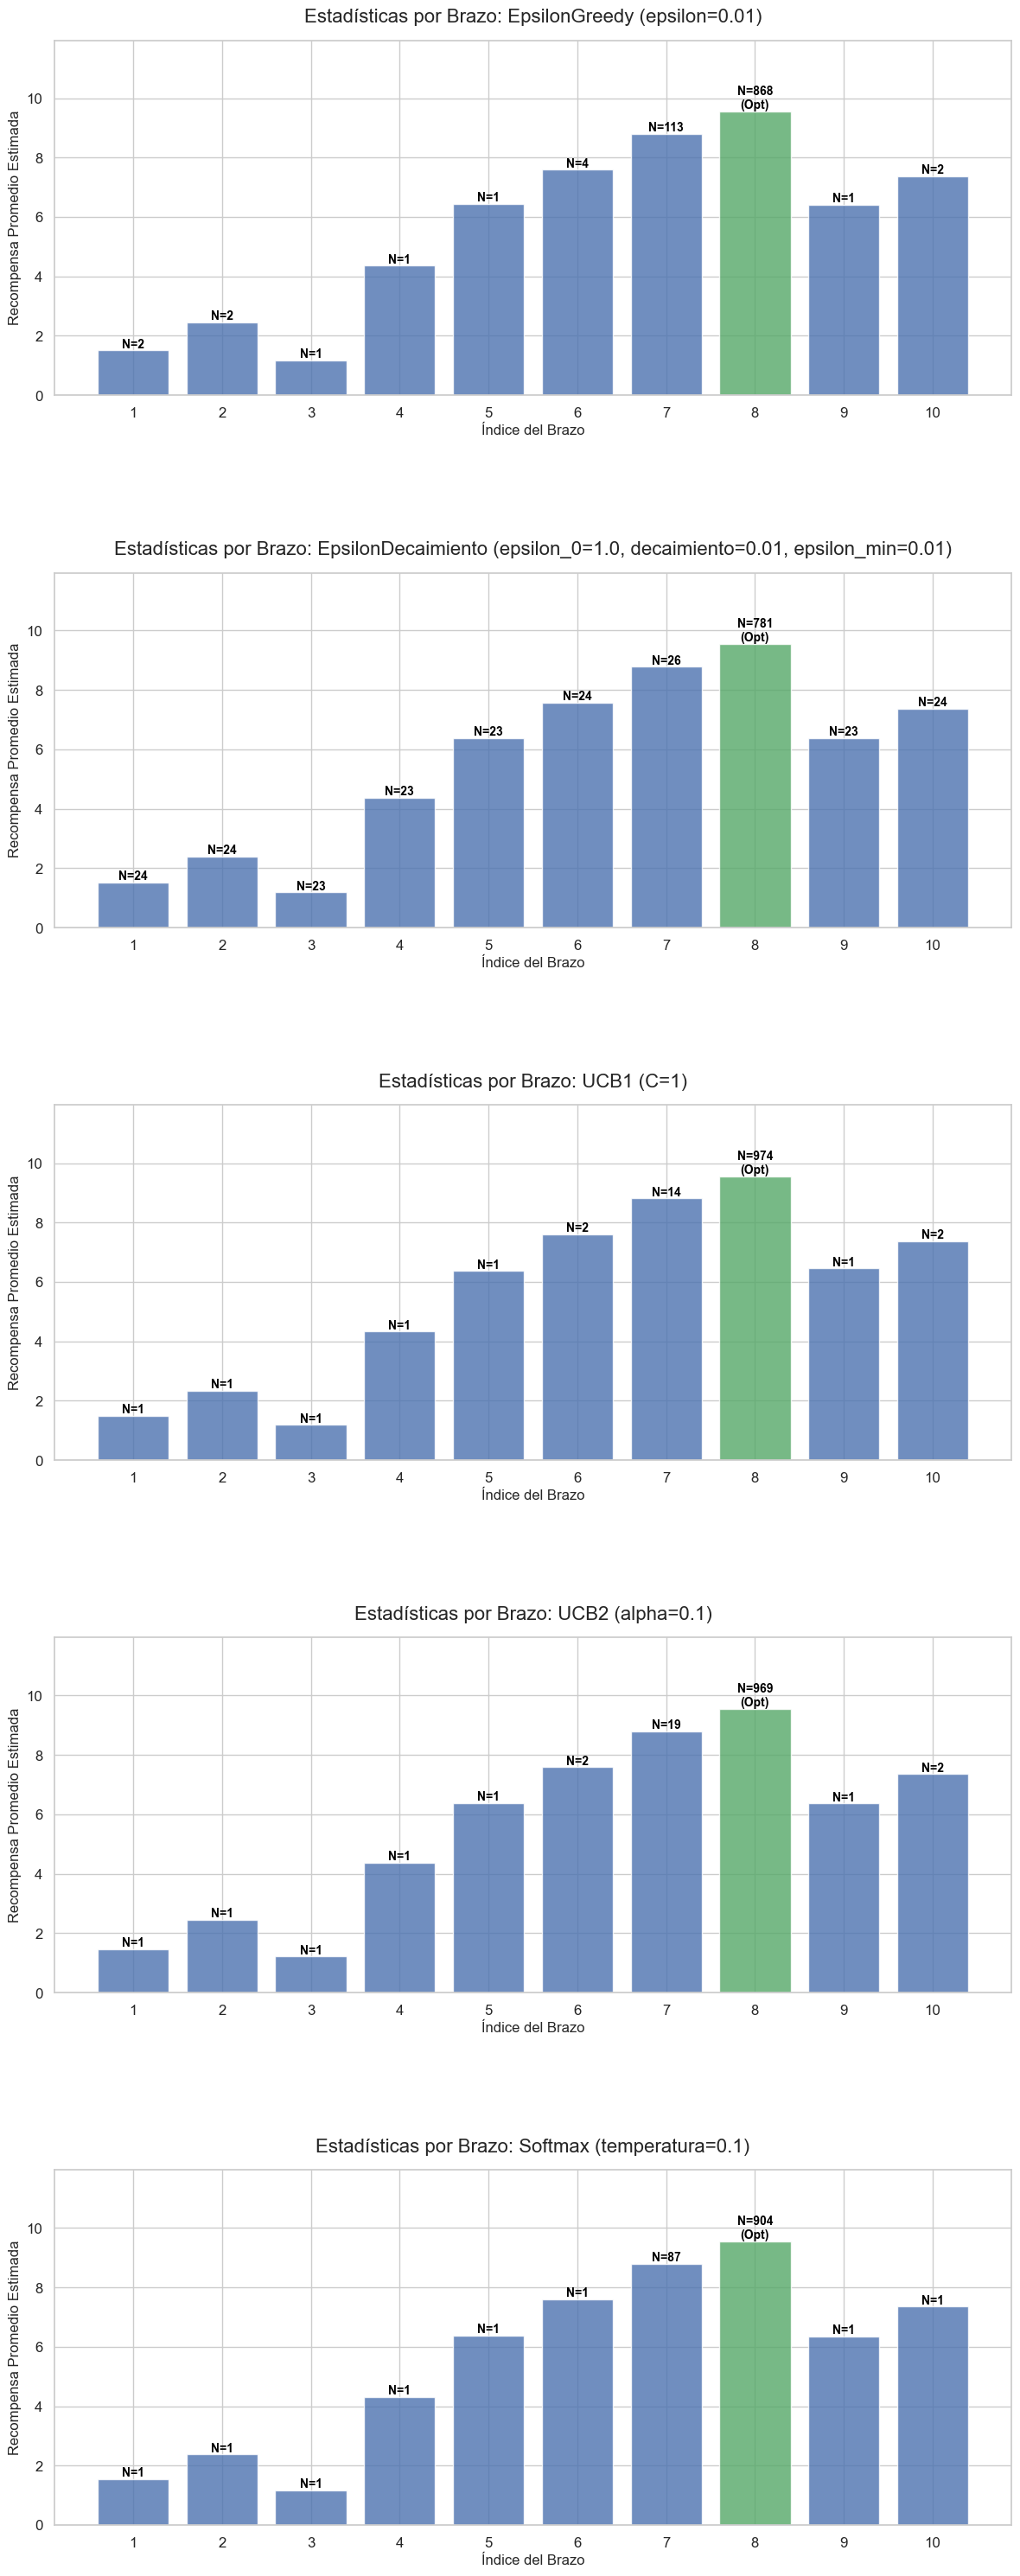

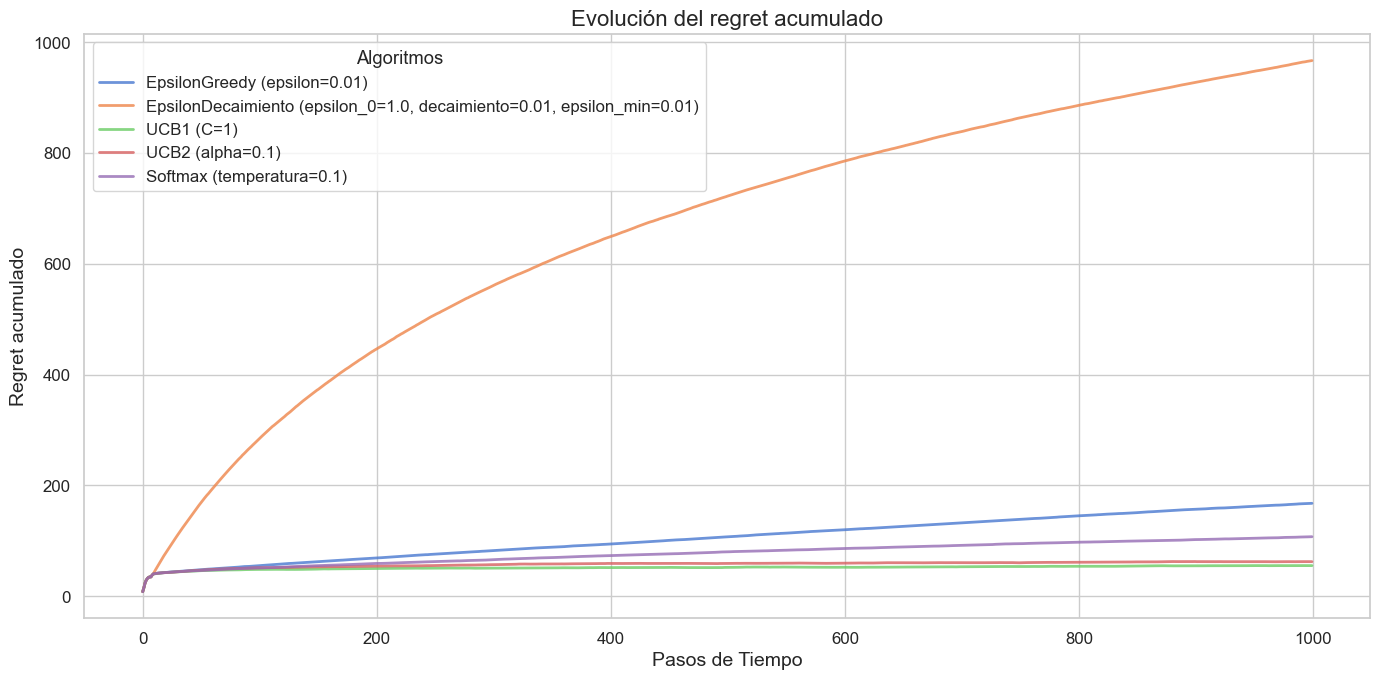

In [7]:
# Graficar los resultados
plot_average_rewards(steps, rewards, algorithms)
plot_optimal_selections(steps, optimal_selections, algorithms)
plot_arm_statistics(arms_stats, algorithms, optimal_arm)
plot_regret(steps, regret_accumulated, algorithms)

#### Análisis detallado de la imagen

En todas las gráficas de líneas aparecen **cinco curvas de colores distintos que representan los algoritmos $\epsilon$-Greedy, $\epsilon$-decaimiento, UCB1, UCB2 y Softmax**:

* **Azul ($\epsilon$ = 0.01):** Estrategia $\epsilon$-Greedy con exploración constante del 1%.
* **Naranja ($\epsilon$-decaimiento):** Estrategia $\epsilon$-Greedy con exploración decreciente en el tiempo.
* **Verde (UCB1):** Algoritmo basado en *Upper Confidence Bound*, que selecciona acciones maximizando una cota superior de confianza.
* **Rojo (UCB2):** Variante más agresiva de UCB que controla explícitamente la duración de las fases de explotación.
* **Morado (Softmax):** Estrategia donde la probabilidad de selección depende exponencialmente de los valores estimados y de la temperatura $\tau$


#### Recompensa promedio vs pasos de tiempo

La gráfica **"Recompensa Promedio vs Pasos de Tiempo"** muestra un comportamiento muy similar para casi todos los algoritmos evaluados. Tras la fase inicial de exploración obligatoria, todas las curvas (UCB1, UCB2, Softmax y $\epsilon$ = 0.01) presentan un **crecimiento abrupto en los primeros pasos** y convergen rápidamente hacia un valor cercano a **9.5**, que coincide con la media del brazo óptimo.

Esto indica que:

* **UCB1 y UCB2** identifican el brazo óptimo con rapidez y concentran pronto sus selecciones en él.
* **Softmax** alcanza prácticamente el mismo nivel de recompensa media, lo que sugiere que su exploración residual no penaliza significativamente.
* **$\epsilon$ = 0.01** también converge al mismo valor, ya que su exploración constante del 1% tiene un impacto muy reducido en la media global cuando el número de pasos es suficientemente grande.

La única excepción es **$\epsilon$-decaimiento**, cuya curva crece de forma mucho más lenta. Su alta exploración inicial retrasa la identificación estable del brazo óptimo, lo que provoca que su recompensa promedio quede por debajo del resto en este experimento. No obstante, con un número mayor de iteraciones, también tendería a alcanzar el mismo valor.

En consecuencia, esta gráfica muestra que **todos los algoritmos (salvo el decaimiento) alcanzan esencialmente la misma recompensa media**.



#### Porcentaje de selección del brazo óptimo

La segunda gráfica, **"Porcentaje de selección del brazo óptimo vs pasos de tiempo"**, evidencia con mayor claridad las diferencias entre algoritmos:

* **UCB2 (99%)** es el que más se aproxima al 100% de selección óptima, mostrando el mejor equilibrio teórico y práctico.
* **UCB1 (98%)** también converge casi completamente, aunque ligeramente por debajo de UCB2.
* **Softmax (95%)** mantiene una probabilidad residual de seleccionar brazos subóptimos debido a su naturaleza probabilística.
* **$\epsilon$-decaimiento (91%)** mejora respecto a $\epsilon$ constante, pero su fase inicial de alta exploración penaliza.
* **$\epsilon$ = 0.01 (89%)** queda ligeramente por debajo en este experimento concreto; sin embargo, con más iteraciones tendería al 99%, ya que su exploración constante del 1% limita la convergencia exacta al 100%.

La diferencia fundamental es que **UCB explora de manera dirigida**, mientras que $\epsilon$-Greedy y Softmax exploran de forma estocástica no informada.


#### Estadísticas por brazo

El histograma de **"Estadísticas por brazo"** muestra el número medio de selecciones por brazo y la recompensa promedio obtenida.

* En **UCB1 y UCB2**, el brazo óptimo concentra casi la totalidad de las selecciones tras la fase inicial de exploración.
* En **Softmax**, todos los brazos mantienen cierta frecuencia de selección debido a la probabilidad exponencial no nula.
* En **$\epsilon$-decaimiento**, la elevada exploración inicial reduce la frecuencia media final del brazo óptimo.
* En **$\epsilon$=0.01**, cada brazo subóptimo sigue siendo seleccionado aproximadamente el 1% del tiempo agregado, lo que impide una concentración total en el óptimo.

La superioridad de UCB2 se refleja en la mayor concentración sobre el brazo óptimo.


#### Regret acumulado

En la gráfica **"Evolución del regret acumulado"** se observa que:

* **$\epsilon$-decaimiento** presenta el mayor regret acumulado. Aunque su crecimiento tiene forma logarítmica, la elevada exploración inicial genera una acumulación de pérdida mucho mayor en los primeros pasos.
* Debido a esta diferencia de escala, las curvas del resto de algoritmos quedan visualmente comprimidas y parecen casi lineales en comparación, aun cuando su crecimiento real no sea estrictamente lineal.
* **UCB1 y UCB2** mantienen un regret claramente menor.
* **Softmax y $\epsilon$ = 0.01** se sitúan en una posición intermedia, con un crecimiento moderado del regret debido a su exploración constante.

## Qué gráficas son más importantes

A la hora de evaluar algoritmos, no todas las gráficas aportan el mismo tipo de información.

### Recompensa promedio

Es una métrica orientada al rendimiento.

**Ventajas:**

* Indica cuánto beneficio medio está obteniendo el algoritmo en cada instante.
* Permite comparar rápidamente qué método alcanza antes valores cercanos al óptimo

**Limitaciones:**

* Puede ocultar diferencias estructurales entre algoritmos (dos métodos pueden tener recompensas medias similares pero comportamientos de exploración muy distintos).

### Porcentaje de selección del brazo óptimo

Es la más intuitiva.

**Ventajas:**

* Mide directamente la capacidad de identificar el brazo óptimo.
* Permite observar la velocidad de convergencia.
* Es fácil de explicar y visualmente muy clara.

**Limitaciones:**

* No distingue entre errores leves y errores graves (todos cuentan igual).

### Estadísticas por brazo 

Esta gráfica es complementaria.

**Ventajas:**

* Sirve para entender cómo se distribuyen las selecciones.
* Indica si la exploración es uniforme o concentrada.

**Limitaciones:**

* No permite comparar rendimiento global fácilmente.

### Regret acumulado

La gráfica de **regret acumulado** está orientada al análisis global del aprendizaje, la consideramos complementaria.

**Ventajas:**

* Refleja tanto la velocidad de aprendizaje como el coste total de la exploración.

**Limitaciones:**

* Puede ser menos intuitiva que la recompensa promedio

Por tanto, las dos más importantes serían la **Recompensa promedio** y el **porcentaje de selección del brazo óptimo**


## Conclusiones

Hemos estudiado un **experimento de toma de decisiones secuenciales** modelado como un **Multi-Armed Bandit (MAB)** comparando los algoritmos **$\epsilon$-greedy, $\epsilon$-decaimiento, UCB1, UCB2 y Softmax**, lo que permite extraer conclusiones más generales sobre los distintos mecanismos de exploración.

En este análisis, las conclusiones se fundamentan principalmente en dos métricas observables y directamente interpretables: la **recompensa promedio** y el **porcentaje de selección del brazo óptimo**, que reflejan tanto el rendimiento práctico como la capacidad de aprendizaje de cada algoritmo.


### **1. Rendimiento en términos de recompensa promedio**

La recompensa promedio muestra que, salvo el caso de $\epsilon$-decaimiento, **todos los algoritmos convergen rápidamente hacia la media del brazo óptimo (9.5)** tras la fase inicial de exploración.

* **UCB1 y UCB2** alcanzan muy rápidamente el valor óptimo y se estabilizan en él.
* **Softmax** obtiene prácticamente la misma recompensa media final.
* **$\epsilon$ = 0.01** también converge al mismo nivel, ya que su exploración constante del 1% tiene un impacto muy reducido en la media global.
* **$\epsilon$-decaimiento** crece más lentamente debido a su elevada exploración inicial y no alcanza el mismo nivel en el número de iteraciones considerado, aunque con más pasos tendería al mismo valor .


### **2. Capacidad de identificar el brazo óptimo**

Las diferencias entre algoritmos se aprecian con mayor claridad en el **porcentaje de selección del brazo óptimo**

Los resultados muestran lo siguiente:

* **UCB2 (99%)** obtiene la mayor tasa de selección correcta.
* **UCB1 (98%)** presenta un comportamiento muy similar.
* **Softmax (95%)** mantiene una exploración residual.
* **$\epsilon$-decaimiento (91%)** queda penalizado por su fuerte exploración inicial.
* **$\epsilon$ = 0.01 (89%)** se sitúa ligeramente por debajo en este experimento, aunque con más iteraciones tendería también al 99% (al igual que el anterior).


### **3. Exploración dirigida vs exploración estocástica**

El experimento pone de manifiesto una diferencia estructural entre enfoques:

* **$\epsilon$-Greedy y Softmax** realizan exploración estocástica.
* **UCB1 y UCB2** emplean exploración dirigida basada en incertidumbre.

En términos de porcentaje de selección óptima, la exploración dirigida resulta más eficiente, ya que reduce exploraciones innecesarias una vez que el brazo óptimo ha sido identificado claramente.


### **4. Influencia del horizonte temporal**

Los resultados también muestran que el comportamiento relativo depende del número de iteraciones:

* Con pocos steps, la exploración inicial de $\epsilon$-decaimiento penaliza su rendimiento observable.
* Con más iteraciones, tanto $\epsilon$-decaimiento como $\epsilon$ = 0.01 tenderían a aproximarse al mismo porcentaje óptimo que los métodos UCB.

Esto indica que, a largo plazo, varios algoritmos pueden alcanzar resultados similares, aunque difieren en la velocidad con la que lo hacen.

### **Conclusión finales**

Basándonos en la recompensa promedio y en el porcentaje de selección del brazo óptimo, podemos concluir que:

* **UCB2 es el algoritmo que muestra el mejor desempeño global en este experimento**, al combinar una rápida convergencia con el mayor porcentaje de selección correcta.
* **UCB1** ofrece resultados prácticamente equivalentes.
* **Softmax** logra un rendimiento sólido, aunque ligeramente inferior.
* **$\epsilon$-decaimiento** mejora respecto a $\epsilon$ constante en teoría, pero su fuerte exploración inicial retrasa su rendimiento.
* **$\epsilon$-Greedy con $\epsilon$ pequeño** puede alcanzar resultados muy buenos con suficientes iteraciones.
